# Chapter 5: Cosine Noise Scheduler

## The Problem with Linear Interpolation

In previous chapters, we mixed noise and image **linearly**:

$$ x_t = t \cdot \text{noise} + (1-t) \cdot \text{image} $$

This seems natural. But there's a hidden problem: **variance**.

When you mix two independent signals, the variance doesn't add linearly — it adds in **squares**:

$$ \text{Var}(C) = a^2 + b^2 \quad \text{where} \quad C = a \cdot A + b \cdot B $$

If $a + b = 1$, then $a^2 + b^2$ is **not constant**. It changes over time. This means the "noisiness" of $x_t$ isn't uniform.

## Why should we care?

In a diffusion process, we want the transition from noise to image to be **smooth and well-behaved**. If the variance fluctuates, the model has to work harder to adapt.

The ideal mixing should satisfy:

$$ a^2 + b^2 = 1 $$

This keeps the **variance constant** throughout the journey.

In [1]:
import data
import utils
import torch
import models
from torch import nn, optim

d:\myProjects\learn and test\image-generator\data\


In [2]:
class Diffusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            models.ResConvBlock(3 + 16, 32, 32, 8),
            models.SkipBlock(
                nn.AvgPool2d(2),
                models.ResConvBlock(32, 64, 64),
                models.SkipBlock(
                    nn.AvgPool2d(2),
                    models.ResConvBlock(64, 128, 128),
                    models.SkipBlock(
                        nn.AvgPool2d(2),
                        models.ResConvBlock(128, 256, 256),
                        models.PositionalEncoding2d(256),
                        models.SelfAttention(256),
                        models.ResConvBlock(256, 256, 128),
                        nn.Upsample(scale_factor=2, mode='bilinear'),
                    ),
                    models.ResConvBlock(256, 128, 64),
                    nn.Upsample(scale_factor=2, mode='bilinear'),
                ),
                models.ResConvBlock(128, 64, 32),
                nn.Upsample(scale_factor=2, mode='bilinear'),
            ),
            models.ResConvBlock(64, 32, 3, 8, last_layer=True),
        )
        self.timestep_embed = models.SinusoidalTimestepEmbedder(16)
    
    def forward(self, x):
        x, t = x
        t = self.timestep_embed(t)
        t = t[..., None, None]
        t = t.repeat(1, 1, 32, 32)
        x = torch.cat([x, t], dim=1)
        return self.net(x)

model = Diffusion()

## Why Sine and Cosine?

We need two coefficients $a$ and $b$ such that:

$$ a^2 + b^2 = 1 $$

The simplest pair that satisfies this is:

$$ a = \sin(\theta), \quad b = \cos(\theta) $$

where $\theta$ goes from $0$ to $\pi/2$ as we go from clean image ($t=0$) to pure noise ($t=1$).

So we set:

$$ \theta = \frac{\pi}{2} \cdot t $$

Now the noisy image becomes:

$$ x_t = \sin\left(\frac{\pi}{2} t\right) \cdot \text{noise} + \cos\left(\frac{\pi}{2} t\right) \cdot \text{image} $$

Check the variance:

$$ \sin^2(\theta) + \cos^2(\theta) = 1 \quad \text{✓} $$

## What About the Flow?

The flow is the **derivative** with respect to time. Based on this, I changed the dataset accordingly:

```python
x = torch.sin(t * torch.pi / 2) * noise + torch.cos(t * torch.pi / 2) * y
target = torch.cos(t * torch.pi / 2) * noise - torch.sin(t * torch.pi / 2) * y

In [3]:
class NoisyCIFAR10(torch.utils.data.Dataset):
    def __init__(self, train = True, normalize = False):
        self.cifar10 = data.get_cifar10(train=train, normalize=normalize)
    
    def __len__(self):
        return len(self.cifar10)
    
    def __getitem__(self, index):
        y, _ = self.cifar10[index]
        noise = torch.randn((3, 32, 32))
        t = torch.rand(1)[0]
        x =  torch.sin(t*torch.pi/2)*noise  +  torch.cos(t*torch.pi/2)*y
        return (x, t), torch.cos(t*torch.pi/2)*noise  -  torch.sin(t*torch.pi/2)*y

dataloader = data.DataLoader(NoisyCIFAR10(), batch_size=50, shuffle=True)
optimizer = optim.Adam(model.parameters(), 1e-3)
loss_fn = nn.MSELoss()

## Two Ways to Sample

Now that the path is curved (circular, not a straight line), the simple Euler integration we used before will drift off the correct trajectory if we take steps that are too large.

We have two ways to handle this. Let's look at the first one.

---

## Method 1: More Steps (Euler Approximation)

If we take a very large number of small steps, each straight step will closely approximate the true curved path. This is the simplest method — just increase `steps` to a high number.

The downside? It's **slow**. More steps means more model evaluations.

Let's implement this method first:

In [4]:
@torch.no_grad()
def sample_euler(num, steps):
    model.eval()
    images = torch.zeros((num * steps, 3, 32, 32))
    image = torch.randn((num, 3, 32, 32))                     # start from pure noise
    
    for step in range(steps, 0, -1):                          # walk backward
        t = step / steps
        v = model((image, torch.tensor(t).repeat(num,)))      # predict flow
        image = image - v / steps                             # Euler step
        images[(steps - step) * num:(steps - step) * num + num] = image
    
    return images

## Method 2: Exact Integration (The Smart Way)

But wait — there's a better way! this way called **v-predict diffusion**

We can use the **trigonometric structure** to stay exactly on the path without needing thousands of steps.

Since the path is curved (circular), the derivative isn't linear. But we can solve the equations exactly.

### The Math Behind It

From the mixing formulas we defined in the dataset:

$$ x_t = \sin(\theta) \cdot \epsilon + \cos(\theta) \cdot x_0 $$

$$ v_t = \cos(\theta) \cdot \epsilon - \sin(\theta) \cdot x_0 $$

Where $\theta = \frac{\pi}{2} \cdot t$, $x_t$ is the noisy image, $v_t$ is the flow (what our model predicts), $x_0$ is the clean image, and $\epsilon$ is the noise.

We have two equations and two unknowns ($x_0$ and $\epsilon$). We can solve:

$$ x_0 = \cos(\theta) \cdot x_t - \sin(\theta) \cdot v_t $$

$$ \epsilon = \sin(\theta) \cdot x_t + \cos(\theta) \cdot v_t $$

### Stepping Backward in Time

Now that we have predicted $x_0$ and $\epsilon$, we can **step backward** to the previous timestep ($\theta_{prev}$) by recombining them with the **previous** coefficients:

$$ x_{prev} = \cos(\theta_{prev}) \cdot x_0 + \sin(\theta_{prev}) \cdot \epsilon $$

This gives us the exact image at the previous noise level — no approximation. We're walking exactly along the true curved path.


Let's implement this smart sampler:

In [5]:
@torch.no_grad()
def sample(num, steps):
    model.eval()
    images = torch.zeros((num * steps, 3, 32, 32))
    image = torch.randn((num, 3, 32, 32))
    
    # Precompute sine and cosine coefficients for each step
    alphas = torch.cos(torch.linspace(0, torch.pi/2, steps + 1))
    sigmas = torch.sin(torch.linspace(0, torch.pi/2, steps + 1))
    
    for step in range(steps, 0, -1):
        t = step / steps
        v = model((image, torch.tensor(t).repeat(num,)))
        
        # Recover predicted clean image and noise
        pred = image * alphas[step] - v * sigmas[step]
        eps = image * sigmas[step] + v * alphas[step]
        
        # Step back to previous timestep
        image = alphas[step-1] * pred + sigmas[step-1] * eps
        
        images[(steps - step) * num:(steps - step) * num + num] = image
    
    return images

### Adding Fresh Noise (Optional)

To improve quality and diversity, we can add a small amount of **fresh noise** at each step. The condition is that we must adjust the mixing coefficients so that:

$$ \text{Var}(\text{new noise}) + \text{Var}(\text{old noise}) = \text{Var}(\text{totla noise}) = \sin(\theta)^2 $$

This keeps the total variance constant throughout the process.

In [6]:
@torch.no_grad()
def sample(num, steps, eta=1.):
    model.eval()
    images = torch.zeros((num * steps, 3, 32, 32))
    image = torch.randn((num, 3, 32, 32))
    
    # Precompute sine and cosine coefficients for each step
    alphas = torch.cos(torch.linspace(0, torch.pi/2, steps + 1))
    sigmas = torch.sin(torch.linspace(0, torch.pi/2, steps + 1))
    
    for step in range(steps, 0, -1):
        t = step / steps
        v = model((image, torch.tensor(t).repeat(num,)))
        
        # Recover predicted clean image and noise
        pred = image * alphas[step] - v * sigmas[step]
        eps = image * sigmas[step] + v * alphas[step]
        
        # Step back to previous timestep
        image = alphas[step-1] * pred + sigmas[step-1] * eps

        if step > 0:
            # If eta > 0, adjust the scaling factor for the predicted noise
            # downward according to the amount of additional noise to add
            ddim_sigma = eta * (sigmas[step - 1]**2 / sigmas[step]**2).sqrt() * \
                (1 - alphas[step]**2 / alphas[step - 1]**2).sqrt()
            adjusted_sigma = (sigmas[step - 1]**2 - ddim_sigma**2).sqrt()

            # Recombine the predicted noise and predicted denoised image in the
            # correct proportions for the next step
            image = pred * alphas[step - 1] + eps * adjusted_sigma

            # Add the correct amount of fresh noise
            if eta:
                image += torch.randn_like(image) * ddim_sigma
        
        images[(steps - step) * num:(steps - step) * num + num] = image
    
    return images

## Training

We'll train using Method 2 (the exact integration) because it gives better quality even with a small number of steps.

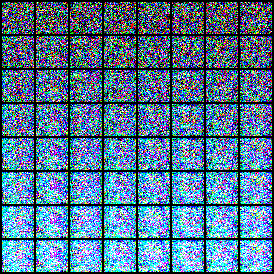

Loss: 0.0828964: 100%|██████████| 1000/1000 [16:30<00:00,  1.01it/s]


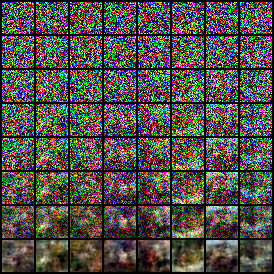

Loss: 0.0714002: 100%|██████████| 1000/1000 [16:02<00:00,  1.04it/s]


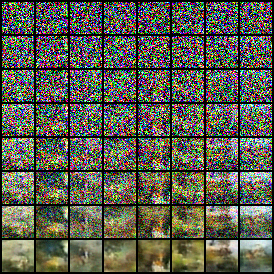

Loss: 0.0712706: 100%|██████████| 1000/1000 [16:14<00:00,  1.03it/s]


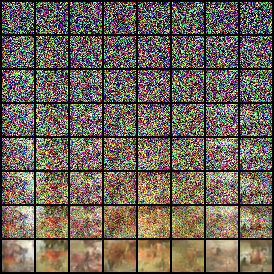

In [7]:
demo = sample(8, 8)
utils.show_image(demo)
for i in range(3):
    utils.train(model, dataloader, optimizer, loss_fn)
    demo = sample(8, 8)
    utils.show_image(demo)

## What We Just Built

We changed two things in this chapter:

1. **The path** — from a straight line to a circular arc using sine and cosine. This keeps the variance constant and makes the journey from noise to image smoother.

2. **The sampler** — from simple Euler steps to exact trigonometric integration. This keeps us on the true curved path without approximation.

## Key Insight

The linear path was simple but flawed — the variance wasn't constant, and the model struggled.

The cosine path fixes this. And the exact integration sampler lets us walk along this curved path accurately, even with a small number of steps.

This combination — a smooth path and an exact sampler — is a big step toward high‑quality image generation.

Next, we'll build on these ideas to create an even more powerful generative model.